In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import zscore
from tqdm import tqdm

In [11]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/master/data/constituents.csv"

sp500 = pd.read_csv(url)

print(sp500.head())

tickers = sp500["Symbol"].tolist()

  Symbol             Security             GICS Sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                GICS Sub-Industry    Headquarters Location  Date added  \
0        Industrial Conglomerates    Saint Paul, Minnesota  1957-03-04   
1               Building Products     Milwaukee, Wisconsin  2017-07-26   
2           Health Care Equipment  North Chicago, Illinois  1957-03-04   
3                   Biotechnology  North Chicago, Illinois  2012-12-31   
4  IT Consulting & Other Services          Dublin, Ireland  2011-07-06   

       CIK      Founded  
0    66740         1902  
1    91142         1916  
2     1800         1888  
3  1551152  2013 (1888)  
4  1467373         1989  


In [12]:
prices = yf.download(
tickers,
period="2y",
auto_adjust=True,
progress=False
)["Close"]

ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['BRK.B']: YFPricesMissingError('possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")')
ERROR:yfinance:['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (period=2y)')


In [13]:
tickers = sp500["Symbol"].tolist()
tickers = [t.replace(".", "-") for t in tickers]

In [14]:
print("BRK-B" in tickers)
print("BF-B" in tickers)

True
True


In [15]:
prices = yf.download(
tickers,
period="2y",
auto_adjust=True,
progress=False
)["Close"]

In [16]:
def get_fundamentals(ticker):

    try:

        stock = yf.Ticker(ticker)

        info = stock.info

        return {
            "Ticker": ticker,
            "PE": info.get("trailingPE"),
            "PB": info.get("priceToBook"),
            "ROE": info.get("returnOnEquity")
        }

    except:
        return None

In [19]:
momentum = (prices.iloc[-1]/prices.iloc[-252]) - 1

In [20]:
volatility = prices.pct_change().std()*np.sqrt(252)

/tmp/ipykernel_7682/245351862.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  volatility = prices.pct_change().std()*np.sqrt(252)


In [36]:
# ==========================================
# COMPLETE FUNDAMENTALS BLOCK
# ==========================================

import pandas as pd
import yfinance as yf

rows = []

for ticker in tickers[:50]:

    try:

        info = yf.Ticker(ticker).info

        pe = info.get("trailingPE")
        roe = info.get("returnOnEquity")

        if pe and pe > 0 and roe is not None:

            rows.append({
                "Ticker": ticker,
                "PE": pe,
                "ROE": roe,
                "Value": 1 / pe,
                "Quality": roe
            })

    except:
        pass

fundamentals = pd.DataFrame(rows)

value = fundamentals.set_index("Ticker")["Value"]
quality = fundamentals.set_index("Ticker")["Quality"]

print(fundamentals.head())

  Ticker         PE      ROE     Value  Quality
0    MMM  31.123077  0.71458  0.032130  0.71458
1    AOS  15.317333  0.28267  0.065286  0.28267
2    ABT  25.358543  0.12334  0.039434  0.12334
3    ACN  10.144568  0.24406  0.098575  0.24406
4   ADBE  11.301087  0.62954  0.088487  0.62954


In [38]:
df = pd.DataFrame()

df["Momentum"] = momentum
df["Volatility"] = volatility

df = df.dropna()

In [39]:
from scipy.stats import zscore

df["Momentum_Z"] = zscore(df["Momentum"])
df["LowVol_Z"] = -zscore(df["Volatility"])

df["Composite"] = (
    df["Momentum_Z"]
    + df["LowVol_Z"]
)

df.sort_values(
    "Composite",
    ascending=False
).head(20)

,Momentum,Volatility,Momentum_Z,LowVol_Z,Composite
Ticker,,,,,
SNDK,40.823215,1.004498,19.699869,-5.235604,14.464265
WDC,10.138916,0.597665,4.754536,-2.057186,2.697349
STX,6.904839,0.549165,3.179321,-1.678270,1.501051
EVRG,0.283489,0.161515,-0.045725,1.350275,1.304550
JNJ,0.619440,0.182666,0.117906,1.185034,1.302939
ATO,0.118576,0.162413,-0.126049,1.343257,1.217209
WEC,0.118308,0.163464,-0.126179,1.335049,1.208870
KO,0.184176,0.168819,-0.094097,1.293217,1.199120
PNW,0.206615,0.170851,-0.083168,1.277341,1.194173


In [40]:
df = pd.DataFrame()

# Price factors
df["Momentum"] = momentum
df["Volatility"] = volatility

# Fundamental factors
df = df.join(value, how="left")
df = df.join(quality, how="left")

# Rename columns
df.columns = [
    "Momentum",
    "Volatility",
    "Value",
    "Quality"
]

# Remove missing values
df = df.dropna()

print(df.head())
print(df.shape)

        Momentum  Volatility     Value  Quality
Ticker                                         
A       0.099713    0.314373  0.039315  0.21331
AAPL    0.466340    0.278698  0.028101  1.41471
ABNB    0.063740    0.360721  0.029168  0.32325
ABT    -0.306773    0.229230  0.039434  0.12334
ACGL    0.028537    0.237768  0.138726  0.21306
(46, 4)


In [41]:
df["Momentum_Z"] = zscore(df["Momentum"])

df["Value_Z"] = zscore(df["Value"])

df["Quality_Z"] = zscore(df["Quality"])

df["LowVol_Z"] = -zscore(df["Volatility"])

In [42]:
df["Composite"] = (
df["Momentum_Z"] +
df["Value_Z"] +
df["Quality_Z"] +
df["LowVol_Z"]
)

In [43]:
df = df.sort_values(
"Composite",
ascending=False
)

In [44]:
df.head(20)

,Momentum,Volatility,Value,Quality,Momentum_Z,Value_Z,Quality_Z,LowVol_Z,Composite
Ticker,,,,,,,,,
ALL,0.190997,0.250366,0.195206,0.45221,-0.142986,3.666531,0.284498,0.589803,4.397846
AAPL,0.466340,0.278698,0.028101,1.41471,0.285429,-0.620388,2.494927,0.367499,2.527467
ACGL,0.028537,0.237768,0.138726,0.21306,-0.395764,2.217587,-0.264722,0.688654,2.245755
T,-0.155833,0.230294,0.133275,0.18370,-0.682631,2.077748,-0.332149,0.747296,1.810264
AMGN,0.311997,0.267534,0.041699,1.01318,0.045281,-0.271532,1.572794,0.455097,1.801639
AMP,-0.089844,0.275682,0.086096,0.66936,-0.579958,0.867412,0.783194,0.391170,1.461818
APA,0.938286,0.493686,0.125365,0.26217,1.019747,1.874835,-0.151938,-1.319376,1.423268
AMAT,2.432065,0.496120,0.018092,0.39692,3.343969,-0.877136,0.157522,-1.338469,1.285887
GOOG,1.090647,0.305369,0.037881,0.38885,1.256810,-0.369471,0.138989,0.158234,1.184561


In [45]:
px.histogram(df,x="Composite")

In [46]:
px.scatter(
df,
x="Momentum",
y="Value",
color="Composite"
)

In [47]:
px.imshow(
df[
["Momentum_Z",
"Value_Z",
"Quality_Z",
"LowVol_Z"]
].corr()
)

In [48]:
top10 = df.head(10).index.tolist()

In [49]:
portfolio_prices = prices[top10]

In [50]:
returns = portfolio_prices.pct_change()

In [51]:
portfolio_return = returns.mean(axis=1)

In [52]:
cumulative = (1 + portfolio_return).cumprod()

years = len(portfolio_return) / 252

cagr = (
    cumulative.iloc[-1]
    ** (1/years)
) - 1

In [53]:
sharpe = (
    portfolio_return.mean()
    /
    portfolio_return.std()
) * np.sqrt(252)

In [54]:
cum = (1+portfolio_return).cumprod()

peak = cum.cummax()

drawdown = (cum - peak)/peak

max_dd = drawdown.min()

In [55]:
win_rate = (
    portfolio_return > 0
).mean()

TOP RANKED STOCKS
['ALL', 'AAPL', 'ACGL', 'T', 'AMGN', 'AMP', 'APA', 'AMAT', 'GOOG', 'GOOGL']


PORTFOLIO PERFORMANCE METRICS
CAGR:               25.73%
Total Return:       57.51%
Sharpe Ratio:       1.45
Annual Volatility:  16.71%
Max Drawdown:       -18.25%
Win Rate:           58.80%


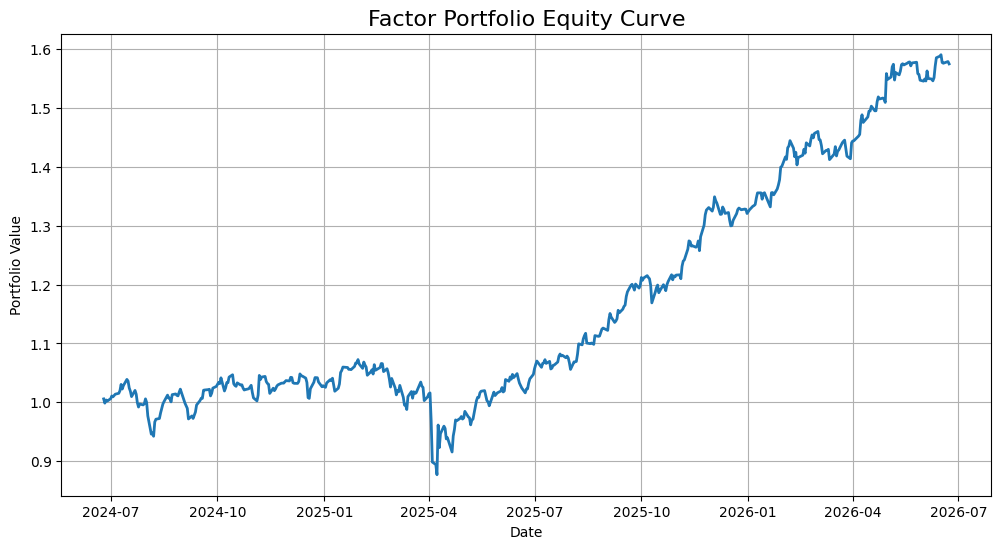

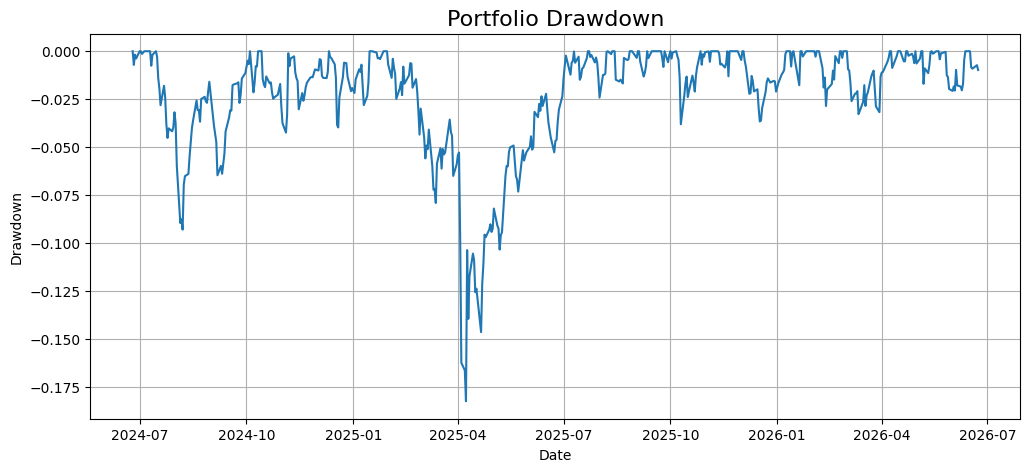

In [56]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if 'df' not in globals():
    raise Exception("df not found. Run factor ranking first.")

if 'prices' not in globals():
    raise Exception("prices not found. Run price download first.")

TOP_N = 10

top_stocks = df.head(TOP_N).index.tolist()

print("=" * 50)
print("TOP RANKED STOCKS")
print("=" * 50)
print(top_stocks)

portfolio_prices = prices[top_stocks]

portfolio_returns = (
    portfolio_prices
    .pct_change()
    .dropna()
)

equal_weight_returns = portfolio_returns.mean(axis=1)

equity_curve = (
    1 + equal_weight_returns
).cumprod()

years = len(equal_weight_returns) / 252

cagr = (
    equity_curve.iloc[-1]
    ** (1 / years)
) - 1

sharpe = (
    equal_weight_returns.mean()
    /
    equal_weight_returns.std()
) * np.sqrt(252)

running_max = equity_curve.cummax()

drawdown = (
    equity_curve
    -
    running_max
) / running_max

max_drawdown = drawdown.min()

win_rate = (
    equal_weight_returns > 0
).mean()

total_return = (
    equity_curve.iloc[-1] - 1
)

annual_volatility = (
    equal_weight_returns.std()
    * np.sqrt(252)
)


print("\n")
print("=" * 50)
print("PORTFOLIO PERFORMANCE METRICS")
print("=" * 50)

print(f"CAGR:               {cagr:.2%}")
print(f"Total Return:       {total_return:.2%}")
print(f"Sharpe Ratio:       {sharpe:.2f}")
print(f"Annual Volatility:  {annual_volatility:.2%}")
print(f"Max Drawdown:       {max_drawdown:.2%}")
print(f"Win Rate:           {win_rate:.2%}")

plt.figure(figsize=(12,6))

plt.plot(
    equity_curve.index,
    equity_curve.values,
    linewidth=2
)

plt.title(
    "Factor Portfolio Equity Curve",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.grid(True)

plt.show()

plt.figure(figsize=(12,5))

plt.plot(
    drawdown.index,
    drawdown.values
)

plt.title(
    "Portfolio Drawdown",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.grid(True)

plt.show()